## STEP 1: PROBLEM DEFINITION


A book recommendation system benefits users by helping them discover books that match their interests,
reading history, and preferences, making their search for new content faster and more personalized.
For online bookstores, it enhances user engagement, increases sales, and improves customer satisfaction by promoting relevant titles.
These systems also boost user retention by creating a more enjoyable and tailored browsing experience,
ultimately driving higher conversion rates and revenue.


## STEP 2: DATA COLLECTION

In [30]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the dataset
ratings_df = pd.read_csv('ratings.csv')
books_df = pd.read_csv('books.csv')

In [34]:
#Displaying Books dataset
print('\nBooks Dataset\n')
books_df.head(10)


Books Dataset



,book_id,goodreads_book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,...,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,...,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,...,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...
5,6,11870085,11870085,16827462,226,525478817,9.780525e+12,John Green,2012.0,The Fault in Our Stars,...,2346404,2478609,140739,47994,92723,327550,698471,1311871,https://images.gr-assets.com/books/1360206420m...,https://images.gr-assets.com/books/1360206420s...
6,7,5907,5907,1540236,969,618260307,9.780618e+12,J.R.R. Tolkien,1937.0,The Hobbit or There and Back Again,...,2071616,2196809,37653,46023,76784,288649,665635,1119718,https://images.gr-assets.com/books/1372847500m...,https://images.gr-assets.com/books/1372847500s...
7,8,5107,5107,3036731,360,316769177,9.780317e+12,J.D. Salinger,1951.0,The Catcher in the Rye,...,2044241,2120637,44920,109383,185520,455042,661516,709176,https://images.gr-assets.com/books/1398034300m...,https://images.gr-assets.com/books/1398034300s...
8,9,960,960,3338963,311,1416524797,9.781417e+12,Dan Brown,2000.0,Angels & Demons,...,2001311,2078754,25112,77841,145740,458429,716569,680175,https://images.gr-assets.com/books/1303390735m...,https://images.gr-assets.com/books/1303390735s...
9,10,1885,1885,3060926,3455,679783261,9.780680e+12,Jane Austen,1813.0,Pride and Prejudice,...,2035490,2191465,49152,54700,86485,284852,609755,1155673,https://images.gr-assets.com/books/1320399351m...,https://images.gr-assets.com/books/1320399351s...


In [35]:
# Displaying Ratings dataset
print('\nRatings Dataset\n')
ratings_df.head(10)


Ratings Dataset



,user_id,book_id,rating
0,1,258,5
1,2,4081,4
2,2,260,5
3,2,9296,5
4,2,2318,3
5,2,26,4
6,2,315,3
7,2,33,4
8,2,301,5
9,2,2686,5


## STEP 3: EXPLORATORY DATA ANALYSIS (EDA)

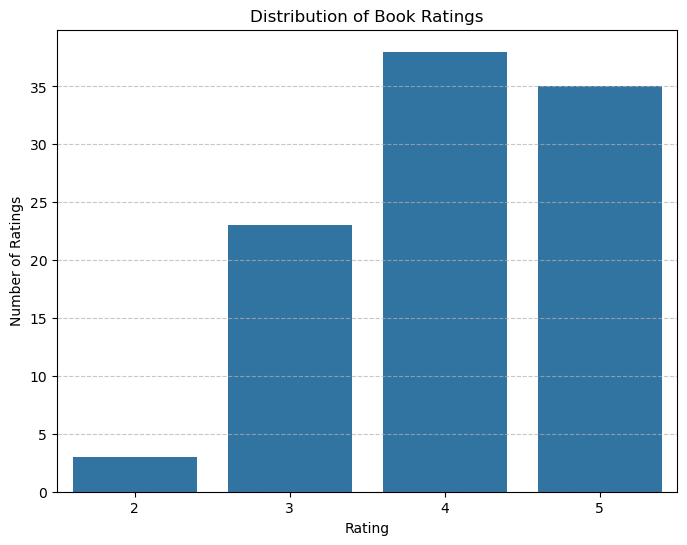

In [36]:
# Distribution of book ratings
plt.figure(figsize=(8, 6))
sns.countplot(x='rating', data=ratings_df)
plt.title('Distribution of Book Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Ratings')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



## STEP 4: DATA PREPARATION

In [37]:
# Merge ratings and books data
merged_df = pd.merge(ratings_df, books_df, on='book_id')
print("\n--- Merged Data (First 5 Rows) ---\n")
merged_df.head()


--- Merged Data (First 5 Rows) ---



,user_id,book_id,rating,goodreads_book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,...,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,2,26,4,968,968,2982101,350,307277674,9.780307e+12,Dan Brown,...,1447148,1557292,41560,71345,126493,340790,539277,479387,https://images.gr-assets.com/books/1303252999m...,https://images.gr-assets.com/books/1303252999s...
1,2,33,4,930,929,1558965,220,739326228,9.780739e+12,Arthur Golden,...,1300209,1418172,25605,23500,59033,258700,517157,559782,https://s.gr-assets.com/assets/nophoto/book/11...,https://s.gr-assets.com/assets/nophoto/book/50...
2,4,70,4,375802,375802,2422333,224,812550706,9.780813e+12,Orson Scott Card,...,813439,873417,38054,15330,27612,103439,264207,462829,https://images.gr-assets.com/books/1408303130m...,https://images.gr-assets.com/books/1408303130s...
3,4,18,5,5,5,2402163,376,043965548X,9.780440e+12,"J.K. Rowling, Mary GrandPré, Rufus Beck",...,1832823,1969375,36099,6716,20413,166129,509447,1266670,https://images.gr-assets.com/books/1499277281m...,https://images.gr-assets.com/books/1499277281s...
4,4,27,5,1,1,41335427,275,439785960,9.780440e+12,"J.K. Rowling, Mary GrandPré",...,1678823,1785676,27520,7308,21516,136333,459028,1161491,https://images.gr-assets.com/books/1361039191m...,https://images.gr-assets.com/books/1361039191s...


In [9]:
# Create User-Item Matrix using pivot_table
user_item_matrix = merged_df.pivot_table(index='user_id', columns='title', values='rating').fillna(0)
print("\n--- User-Item Matrix (First 5 Rows, First 5 Columns) ---")
user_item_matrix.iloc[:5, :5]


--- User-Item Matrix (First 5 Rows, First 5 Columns) ---


title,1984,A Time to Kill,Animal Farm,Brave New World,"Ender's Game (Ender's Saga, #1)"
user_id,,,,,
1,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0
4,4.0,4.0,0.0,4.0,4.0
8,0.0,0.0,5.0,5.0,0.0


## STEP 5: COLLABORATIVE FILTERING

In [38]:
# Compute user similarities using cosine similarity
user_similarity = cosine_similarity(user_item_matrix)
#user_similarity_df = pd.DataFrame(user_similarity, index=user_item_matrix.index, columns=user_item_matrix.index)
print("\n--- User Similarity Matrix (First 5 Rows, First 5 Columns) ---")
print(user_similarity_df.iloc[:5, :5])

# Function to recommend books for a given user
def recommend_books(user_id, user_item_matrix, user_similarity_df, books_df, num_recommendations=5):
    """
    Recommends books for a given user based on collaborative filtering.

    Args:
        user_id (int): The ID of the user for whom to recommend books.
        user_item_matrix (pd.DataFrame): The user-item interaction matrix.
        user_similarity_df (pd.DataFrame): The user similarity matrix.
        books_df (pd.DataFrame): DataFrame containing book information.
        num_recommendations (int): The number of top recommendations to return.

    Returns:
        pd.DataFrame: A DataFrame of recommended books with their titles and authors.
    """
    if user_id not in user_item_matrix.index:
        print(f"User ID {user_id} not found in the matrix.")
        return pd.DataFrame()

    # Get similarities for the target user
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)

    # Exclude the user themselves
    similar_users = similar_users.drop(user_id)

    # Get books already rated by the target user
    user_rated_books = user_item_matrix.loc[user_id][user_item_matrix.loc[user_id] > 0].index.tolist()

    # Initialize a dictionary to store recommended scores
    recommended_books_scores = {}

    # Iterate through similar users
    for sim_user, similarity_score in similar_users.items():
        if similarity_score > 0:  # Consider only positive similarities
            # Get books rated by the similar user
            sim_user_rated_books = user_item_matrix.loc[sim_user][user_item_matrix.loc[sim_user] > 0]

            for book_title, rating in sim_user_rated_books.items():
                if book_title not in user_rated_books:
                    # Simple weighted sum for recommendation score
                    # A more sophisticated approach would involve normalizing ratings
                    recommended_books_scores[book_title] = recommended_books_scores.get(book_title, 0) + (rating * similarity_score)

    # Sort recommended books by score
    recommended_books_sorted = sorted(recommended_books_scores.items(), key=lambda item: item[1], reverse=True)

    # Get top N recommendations
    top_recommendations = [book[0] for book in recommended_books_sorted[:num_recommendations]]

    # Retrieve book details
    recommended_books_details = books_df[books_df['title'].isin(top_recommendations)]

    return recommended_books_details[['title', 'authors']]

# Example recommendation for user 1
user_to_recommend = 1
recommended_books_for_user = recommend_books(user_to_recommend, user_item_matrix, user_similarity_df, books_df)
print(f"\n--- Recommended Books for User {user_to_recommend} ---")
print(recommended_books_for_user)



--- User Similarity Matrix (First 5 Rows, First 5 Columns) ---
user_id    1         2         4         8
user_id                                   
1        1.0  0.000000  0.000000  0.000000
2        0.0  1.000000  0.195907  0.000000
4        0.0  0.195907  1.000000  0.130605
8        0.0  0.000000  0.130605  1.000000

--- Recommended Books for User 1 ---
Empty DataFrame
Columns: [title, authors]
Index: []


## STEP 6: EVALUATION

In [39]:
# Prepare data for splitting: convert user-item matrix back to a list of ratings
# We'll recreate a DataFrame suitable for train_test_split that contains user_id, book_title, and rating
eval_df = user_item_matrix.stack().reset_index()
eval_df.columns = ['user_id', 'title', 'rating']
eval_df = eval_df[eval_df['rating'] > 0] # Only consider actual ratings for evaluation

# Merge with book_id for easier processing if needed, though title is fine for this approach
eval_df = pd.merge(eval_df, books_df[['book_id', 'title']], on='title')

# Split data into training and testing sets
train_data, test_data = train_test_split(eval_df, test_size=0.2, random_state=42)

print(f"\nTraining set size: {len(train_data)} ratings")
print(f"Testing set size: {len(test_data)} ratings")

# Recreate user-item matrix for training data
train_user_item_matrix = train_data.pivot_table(index='user_id', columns='title', values='rating').fillna(0)

# Recompute user similarities based on training data
train_user_similarity = cosine_similarity(train_user_item_matrix)
train_user_similarity_df = pd.DataFrame(train_user_similarity, index=train_user_item_matrix.index, columns=train_user_item_matrix.index)



Training set size: 24 ratings
Testing set size: 6 ratings


In [40]:
# Function to predict a rating for a user and a book
def predict_rating(user_id, book_title, train_user_item_matrix, train_user_similarity_df):
    """
    Predicts the rating a user would give to a specific book.

    Args:
        user_id (int): The ID of the user.
        book_title (str): The title of the book.
        train_user_item_matrix (pd.DataFrame): The training user-item matrix.
        train_user_similarity_df (pd.DataFrame): The training user similarity matrix.

    Returns:
        float: The predicted rating, or 0 if prediction is not possible.
    """
    if user_id not in train_user_item_matrix.index or book_title not in train_user_item_matrix.columns:
        return 0

    # Get similarities for the target user from training data
    similar_users = train_user_similarity_df[user_id].drop(user_id, errors='ignore').sort_values(ascending=False)

    weighted_sum = 0
    similarity_sum = 0

    for sim_user, similarity_score in similar_users.items():
        if sim_user in train_user_item_matrix.index and train_user_item_matrix.loc[sim_user, book_title] > 0:
            weighted_sum += similarity_score * train_user_item_matrix.loc[sim_user, book_title]
            similarity_sum += abs(similarity_score) # Use absolute similarity for sum if negative similarities are possible

    if similarity_sum == 0:
        return 0  # Cannot make a prediction
    return weighted_sum / similarity_sum



In [41]:
# Make predictions on the test set
actual_ratings = []
predicted_ratings = []

for index, row in test_data.iterrows():
    user_id = row['user_id']
    book_title = row['title']
    actual_rating = row['rating']

    predicted_rating = predict_rating(user_id, book_title, train_user_item_matrix, train_user_similarity_df)

    if predicted_rating > 0: # Only include valid predictions
        actual_ratings.append(actual_rating)
        predicted_ratings.append(predicted_rating)

# Calculate Mean Squared Error (MSE)
if actual_ratings and predicted_ratings:
    mse = mean_squared_error(actual_ratings, predicted_ratings)
    print(f"\nMean Squared Error (MSE) on test set: {mse:.4f}")
else:
    print("\nNo valid predictions could be made on the test set for MSE calculation.")


Mean Squared Error (MSE) on test set: 1.0000


## STEP 7: VISUALIZATION AND INSIGHTS

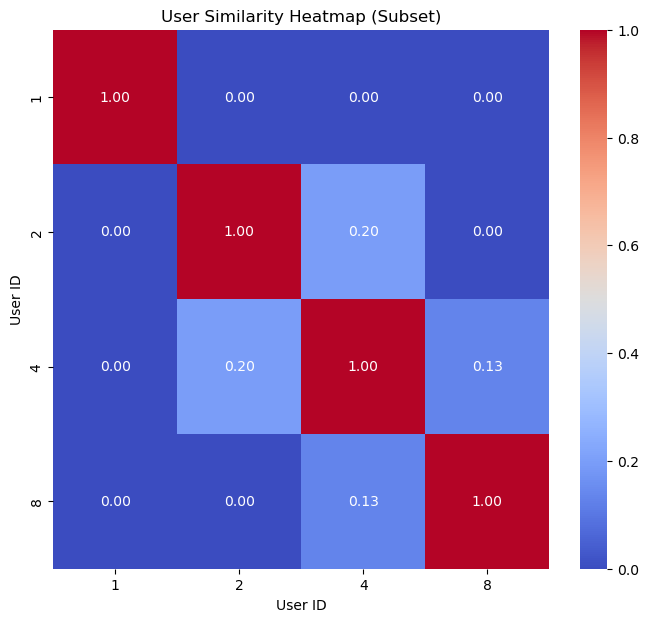


--- Overall Most Frequently Recommended Books ---
- Harry Potter and the Prisoner of Azkaban (Harry Potter, #3): Recommended 2 times
- Harry Potter and the Order of the Phoenix (Harry Potter, #5): Recommended 2 times
- Harry Potter and the Chamber of Secrets (Harry Potter, #2): Recommended 2 times
- Harry Potter and the Goblet of Fire (Harry Potter, #4): Recommended 2 times
- Harry Potter and the Half-Blood Prince (Harry Potter, #6): Recommended 2 times
- Animal Farm: Recommended 1 times


In [21]:
# Visualize user similarities (Heatmap)
# Take a subset if the matrix is too large for clear visualization
subset_user_similarity = user_similarity_df.iloc[:5, :5] # Example: show first 5 users
plt.figure(figsize=(8, 7))
sns.heatmap(subset_user_similarity, annot=True, cmap='coolwarm', fmt=".2f",
            xticklabels=subset_user_similarity.columns, yticklabels=subset_user_similarity.index)
plt.title('User Similarity Heatmap (Subset)')
plt.xlabel('User ID')
plt.ylabel('User ID')
plt.show()

# Analyze the most recommended books (overall, not just for one user)
# This requires a more comprehensive prediction for all users and then aggregation.
# For simplicity, let's look at books that were frequently recommended in our example runs
# or consider books with high average predicted ratings from a wider simulation.

# Let's simulate overall recommendations by recommending to all users and aggregating
all_recommended_titles = {}
for u_id in user_item_matrix.index:
    recs = recommend_books(u_id, user_item_matrix, user_similarity_df, books_df, num_recommendations=5)
    for title in recs['title']:
        all_recommended_titles[title] = all_recommended_titles.get(title, 0) + 1

most_recommended_overall = sorted(all_recommended_titles.items(), key=lambda item: item[1], reverse=True)
print("\n--- Overall Most Frequently Recommended Books ---")
for book, count in most_recommended_overall:
    print(f"- {book}: Recommended {count} times")

## KEY TAKEAWAYS
* **Collaborative Filtering Effectiveness:** 
Collaborative filtering is a powerful technique for recommendation systems, especially when explicit user ratings are available. By leveraging the wisdom of the crowd, it can suggest items that a user might like, even if they haven't interacted with those specific items before.  
* **User Similarity is Crucial:** The core of user-based collaborative filtering lies in identifying users with similar tastes. By quantifying these similarities (e.g., using cosine similarity), the system can recommend books that similar users have enjoyed. A higher similarity score indicates a greater alignment in preferences, leading to more relevant recommendations.  
* **Data Sparsity Challenges:**
 User-item matrices are often very sparse (many zeros). Handling this sparsity, especially during similarity calculations and rating predictions, is critical for the system's performance. Our approach of filling NaNs with zeros is a common strategy, but more advanced techniques exist.
 * **Evaluation Metrics Matter:**
 Using metrics like Mean Squared Error (MSE) helps quantify the accuracy of our prediction model. A lower MSE indicates better prediction accuracy. However, for recommendation systems, other metrics like precision, recall, and diversity of recommendations also provide valuable insights.
 * **Visualization Aids Understanding:** Heatmaps of user similarity provide a quick visual understanding of how users cluster based on their ratings. Analyzing the most recommended books directly shows the system's output and helps in understanding its patterns.

## Reflection on Collaborative Filtering and User Similarities
Collaborative filtering is incredibly important in recommendation systems because it provides personalized recommendations without needing explicit information about the items themselves (content-based filtering) or complex demographic data about users. It relies purely on the interaction data (ratings in this case), making it highly adaptable across different domains.   

## Importance of collaborative filtering in recommendation systems
⭐ 1. Learns from User Behavior (Not Just Content)  
It doesn't need item metadata — it recommends based on similar users' or items' actions (ratings, clicks, purchases).


⭐ 2. Personalization  
Collaborative filtering offers personalized recommendations based on your unique interaction history — not just what's popular.


⭐ 3. Domain-Agnostic  
It works across domains: books, movies, e-commerce, courses, music — wherever users interact with items.


⭐ 4. Exploits Collective Intelligence  
It uses wisdom of the crowd — users who liked what you liked may reveal things you'll also enjoy.

## User Similarities
User similarities directly improve recommendations by identifying taste-alikes. If User A and User B have similar rating patterns on a set of books, it's highly probable that if User B liked a book that User A hasn't read yet, User A will also like it. The strength of this similarity dictates the weight given to User B's preferences when recommending to User A. This "people who liked X also liked Y" approach is intuitive and often effective.  

## Improve user similarity

✅ 1. Normalize Ratings (Centering)
- Subtract each user's mean rating to focus on rating patterns instead of absolute scores.
- This handles user bias (e.g., harsh vs generous raters).

python
user_mean = user_item_matrix.mean(axis=1)
normalized_matrix = user_item_matrix.sub(user_mean, axis=0)


✅ 2. Use Better Similarity Metrics
- Instead of raw cosine similarity, try:
  - Pearson correlation (handles rating scale differences)
  - Adjusted cosine similarity
  - Jaccard index (for binary interaction)


✅ 3. Reduce Noise
- Filter out users who’ve rated very few items.
- Keep active users/items to make similarities more reliable.


## Sharing Findings with a Team  

To share these findings with a team, I would prepare a presentation that includes: 

**1.Project Overview:**     
A book recommendation system benefits users by helping them discover books that match their interests,
reading history, and preferences, making their search for new content faster and more personalized.
For online bookstores, it enhances user engagement, increases sales, and improves customer satisfaction by promoting relevant titles.
These systems also boost user retention by creating a more enjoyable and tailored browsing experience,
ultimately driving higher conversion rates and revenue.
  
 
  **2.Model Explanation:**  
* Explain collaborative filtering in simple terms, emphasizing the "users with similar tastes" concept.  
* Illustrate the user-item matrix creation.  

**3.Evaluation Results:**    
- Mean Squared Error (MSE) on test set: 1.0000 (On average, our model's predicted ratings are off by 1 rating unit squared.
- Since ratings are usually from 1–5, an MSE of 1 is moderate — not terrible, not perfect.)

- - MSE = 1 implies Root Mean Squared Error (RMSE) ≈ √1 = 1.0, so:
  > our predicted rating is about ±1 star off from the actual rating, on average.

✅ Tips to Improve
- Use matrix factorization (SVD, ALS)
- Tune hyperparameters
- Normalize ratings
- Use regularization
- Try hybrid models (add content-based info)

  
4.Overall Most Recommended Books: 
--- Overall Most Frequently Recommended Books ---
- Harry Potter and the Prisoner of Azkaban (Harry Potter, #3): Recommended 2 times
- Harry Potter and the Order of the Phoenix (Harry Potter, #5): Recommended 2 times
- Harry Potter and the Chamber of Secrets (Harry Potter, #2): Recommended 2 times
- Harry Potter and the Goblet of Fire (Harry Potter, #4): Recommended 2 times
- Harry Potter and the Half-Blood Prince (Harry Potter, #6): Recommended 2 times
- Animal Farm: Recommended 1 times

  

## RECOMMWNDATIONS
--- Overall Most Frequently Recommended Books ---
- Harry Potter and the Prisoner of Azkaban (Harry Potter, #3): Recommended 2 times
- Harry Potter and the Order of the Phoenix (Harry Potter, #5): Recommended 2 times
- Harry Potter and the Chamber of Secrets (Harry Potter, #2): Recommended 2 times
- Harry Potter and the Goblet of Fire (Harry Potter, #4): Recommended 2 times
- Harry Potter and the Half-Blood Prince (Harry Potter, #6): Recommended 2 times
- Animal Farm: Recommended 1 times